Note: you may need to restart the kernel to use updated packages.


C:\Users\leahm\AppData\Local\Temp\ipykernel_25040\1234766838.py:19: DeprecationWarning: The LONGITUDE_FORMATTER module-level attribute was deprecated in Cartopy 0.26. Use LongitudeFormatter instead.
  from cartopy.mpl.gridliner import (
C:\Users\leahm\AppData\Local\Temp\ipykernel_25040\1234766838.py:19: DeprecationWarning: The LATITUDE_FORMATTER module-level attribute was deprecated in Cartopy 0.26. Use LatitudeFormatter instead.
  from cartopy.mpl.gridliner import (


Using previously downloaded ETOPO file:
map_data\ETOPO_2022_Horn_of_Africa.nc
<xarray.Dataset> Size: 8MB
Dimensions:    (latitude: 1321, longitude: 1561)
Coordinates:
  * latitude   (latitude) float64 11kB -4.992 -4.975 -4.958 ... 16.99 17.01
  * longitude  (longitude) float64 12kB 32.01 32.03 32.04 ... 57.97 57.99 58.01
Data variables:
    z          (latitude, longitude) float32 8MB ...
Attributes: (12/42)
    cdm_data_type:                             Grid
    Conventions:                               CF-1.6, COARDS, ACDD-1.3
    creator_email:                             Barry.Eakins@noaa.gov
    creator_name:                              NOAA NCEI
    creator_type:                              institution
    creator_url:                               https://www.ngdc.noaa.gov/mgg/...
    ...                                        ...
    sourceUrl:                                 (local files)
    Southernmost_Northing:                     -4.991666666666674
    standard_name_vo

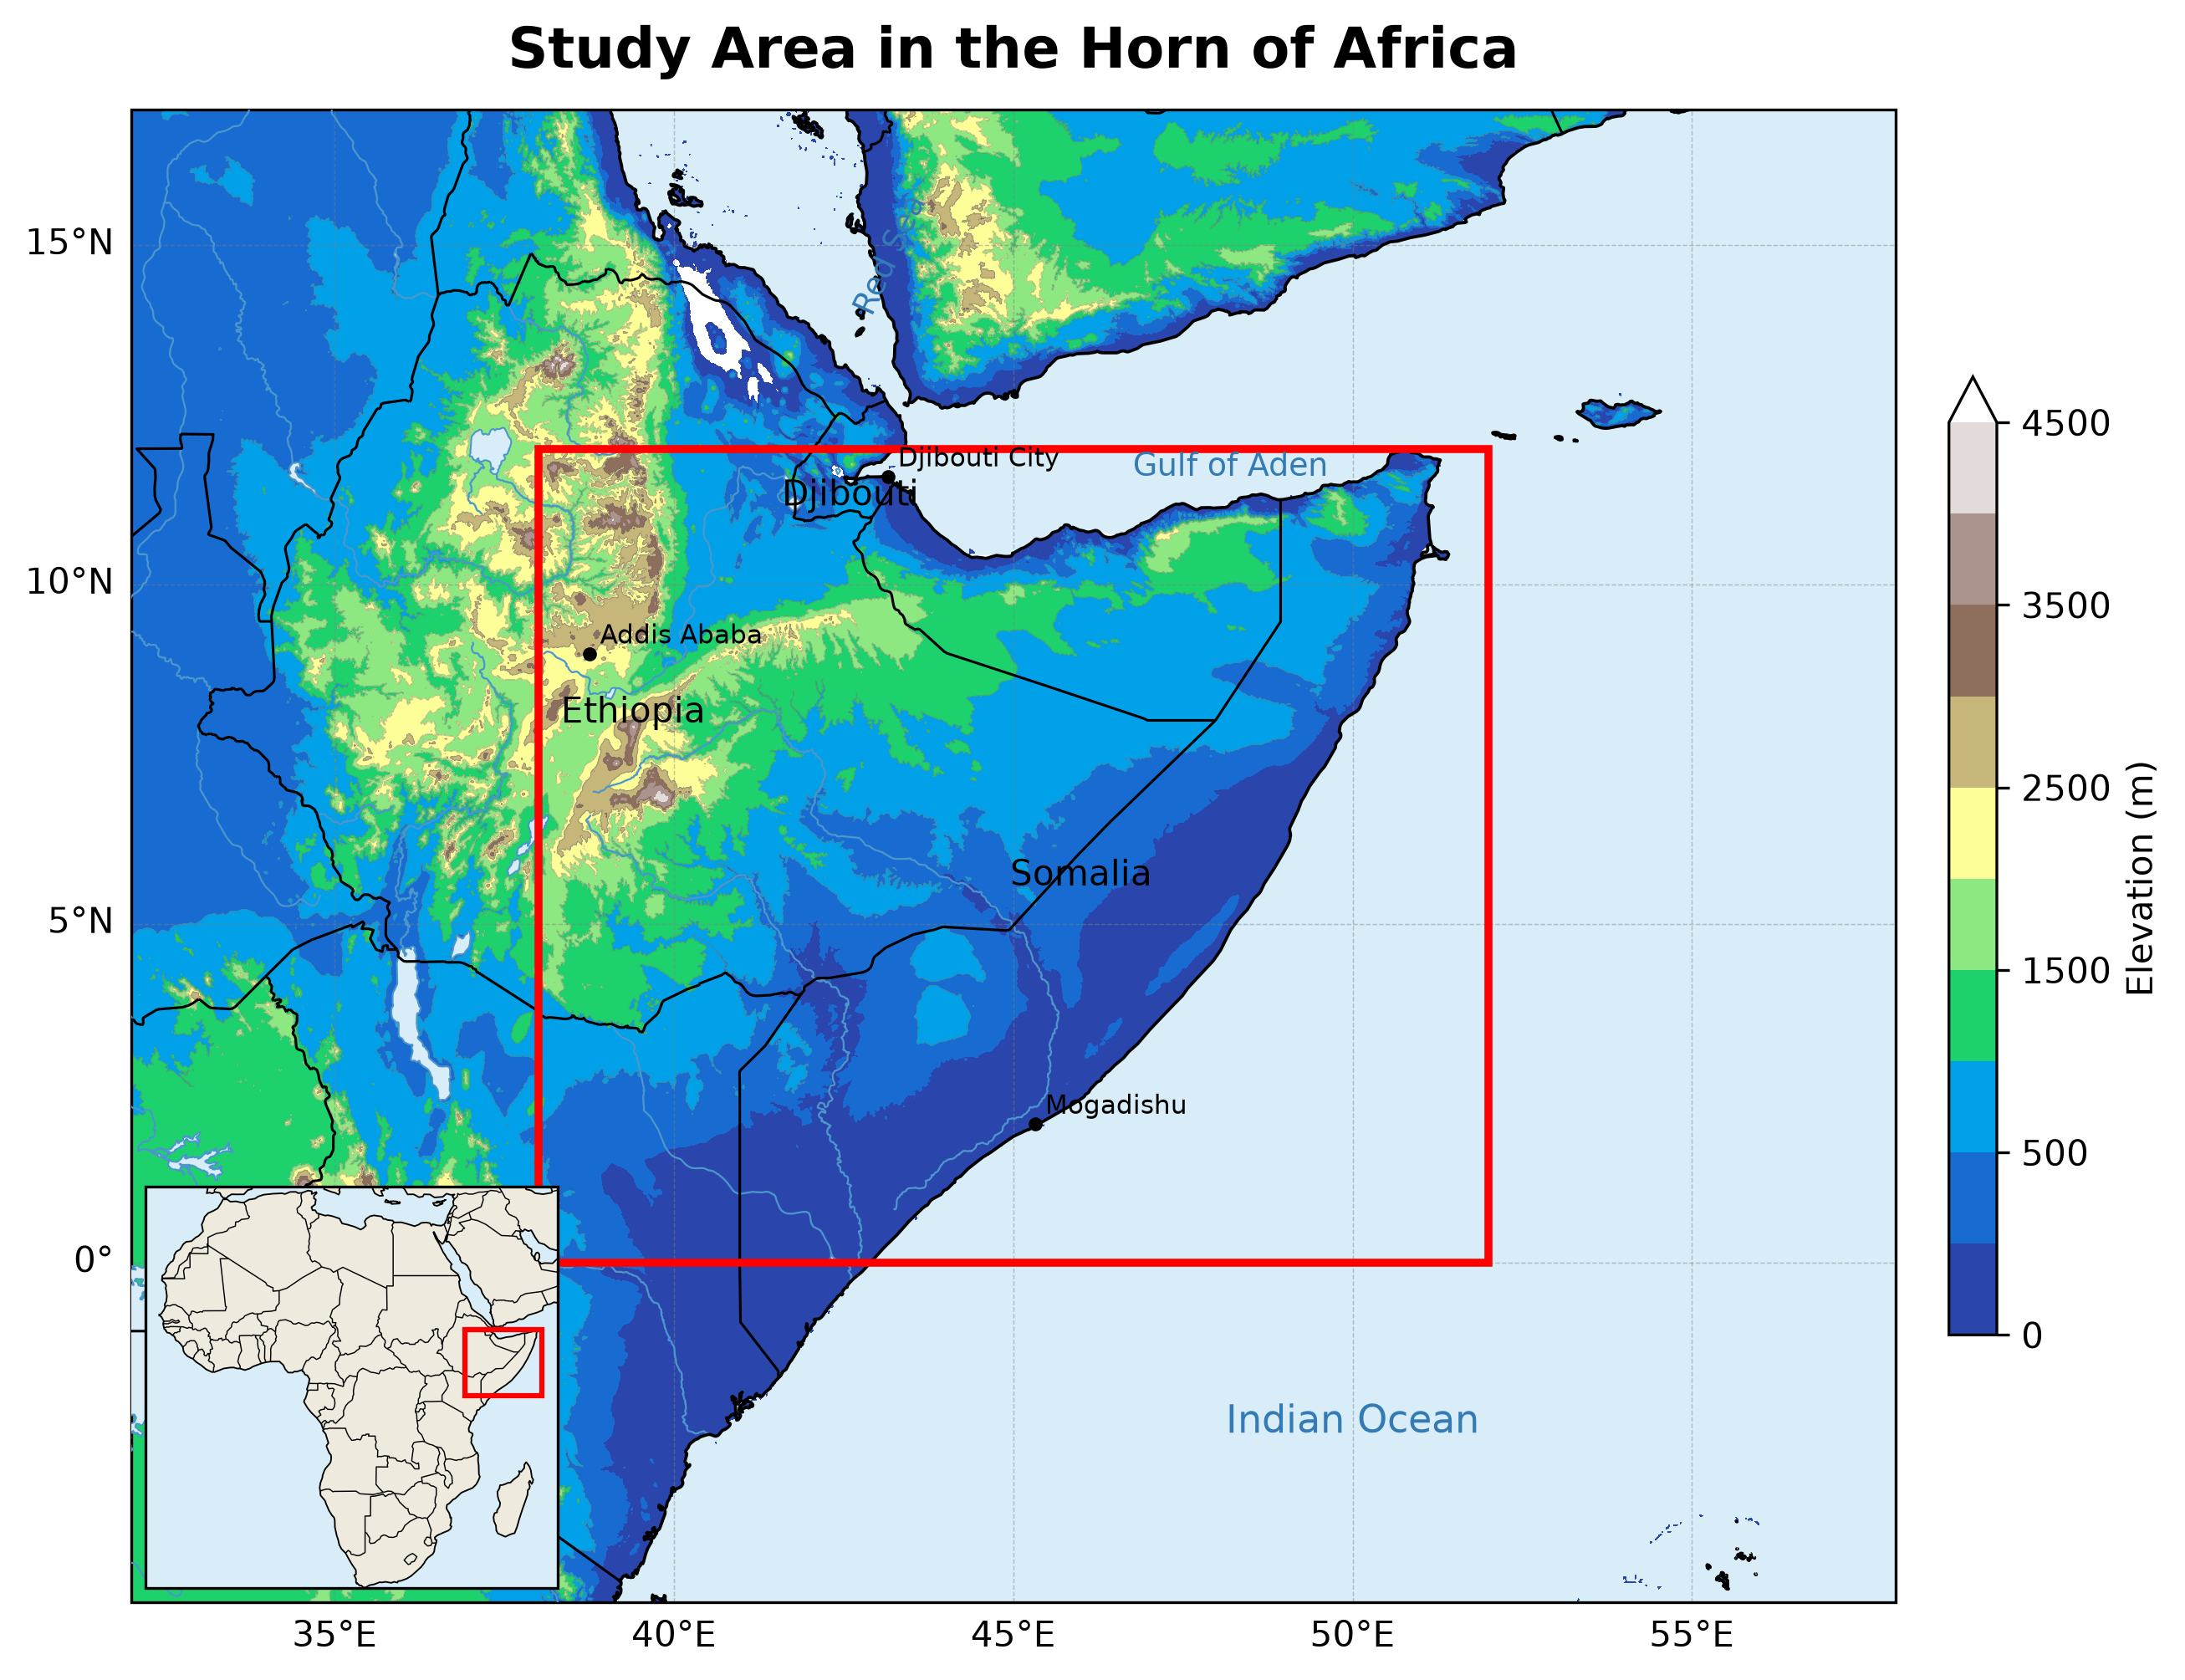

In [1]:
# =============================================================================
# STUDY AREA MAP WITH ONLINE ETOPO 2022 ELEVATION
# Downloads only the required regional subset and caches it locally
# =============================================================================

%pip install requests

import os
from pathlib import Path
import requests
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cartopy.mpl.gridliner import (
    LONGITUDE_FORMATTER,
    LATITUDE_FORMATTER
)

from matplotlib.patches import Rectangle
import config


# =============================================================================
# 1. STUDY REGION FROM CONFIG
# =============================================================================

bounds = config.BOUNDS["study"]

LON_MIN = float(bounds["lon_min"])
LON_MAX = float(bounds["lon_max"])
LAT_MIN = float(bounds["lat_min"])
LAT_MAX = float(bounds["lat_max"])


# =============================================================================
# 2. MAP EXTENT
# =============================================================================
# Slightly larger than the study box so surrounding geography is visible.

MAP_LON_MIN = LON_MIN - 6
MAP_LON_MAX = LON_MAX + 6

MAP_LAT_MIN = LAT_MIN - 5
MAP_LAT_MAX = LAT_MAX + 5


# =============================================================================
# 3. DOWNLOAD ETOPO 2022 FROM NOAA ERDDAP
# =============================================================================
# NOAA ETOPO 2022:
# Dataset ID: ETOPO_2022_v1_60s
# Variable: z
# Resolution: 60 arc-seconds (~1 arc-minute)
#
# Only the map region is downloaded.
# The file is saved locally and will not be downloaded again if it exists.
# =============================================================================

data_dir = Path("map_data")
data_dir.mkdir(exist_ok=True)

ETOPO_FILE = data_dir / "ETOPO_2022_Horn_of_Africa.nc"

BASE_URL = (
    "https://oceanwatch.pifsc.noaa.gov/erddap/griddap/"
    "ETOPO_2022_v1_60s.nc"
)

# ETOPO longitude runs from 0 to 360 degrees.
# The Horn of Africa uses positive east longitudes, so no conversion is needed.

lat_start = MAP_LAT_MIN
lat_stop = MAP_LAT_MAX

lon_start = MAP_LON_MIN
lon_stop = MAP_LON_MAX

# stride = 1 keeps the full 1 arc-minute ETOPO resolution.
# Change to 2 if you want a smaller/faster download.
STRIDE = 1

query = (
    f"z"
    f"[({lat_start}):{STRIDE}:({lat_stop})]"
    f"[({lon_start}):{STRIDE}:({lon_stop})]"
)

download_url = f"{BASE_URL}?{query}"


if not ETOPO_FILE.exists():

    print("Downloading ETOPO 2022 elevation data...")
    print("This happens only once.")

    response = requests.get(
        download_url,
        timeout=180
    )

    response.raise_for_status()

    with open(ETOPO_FILE, "wb") as f:
        f.write(response.content)

    print(f"Saved to: {ETOPO_FILE}")

else:

    print("Using previously downloaded ETOPO file:")
    print(ETOPO_FILE)


# =============================================================================
# 4. OPEN ELEVATION DATA
# =============================================================================

ds_topo = xr.open_dataset(ETOPO_FILE)

print(ds_topo)

elev = ds_topo["z"]


# =============================================================================
# 5. PREPARE LAND ELEVATION
# =============================================================================
# ETOPO includes both topography and bathymetry.
# For this map, keep positive elevation only.

land_elev = elev.where(elev > 0)


# =============================================================================
# 6. CREATE FIGURE
# =============================================================================

fig = plt.figure(
    figsize=(11, 8),
    dpi=300
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.set_extent(
    [
        MAP_LON_MIN,
        MAP_LON_MAX,
        MAP_LAT_MIN,
        MAP_LAT_MAX
    ],
    crs=ccrs.PlateCarree()
)


# =============================================================================
# 7. OCEAN
# =============================================================================

ax.add_feature(
    cfeature.OCEAN,
    facecolor="#d8edf7",
    zorder=0
)


# =============================================================================
# 8. ACTUAL ELEVATION SHADING
# =============================================================================

elevation_levels = [
    0,
    250,
    500,
    1000,
    1500,
    2000,
    2500,
    3000,
    3500,
    4000,
    4500
]

terrain = ax.contourf(
    land_elev["longitude"],
    land_elev["latitude"],
    land_elev,
    levels=elevation_levels,
    cmap="terrain",
    extend="max",
    transform=ccrs.PlateCarree(),
    zorder=1
)


# =============================================================================
# 9. ELEVATION CONTOURS
# =============================================================================
# Light contours help the Ethiopian Highlands appear clearly.

ax.contour(
    land_elev["longitude"],
    land_elev["latitude"],
    land_elev,
    levels=[
        500,
        1000,
        1500,
        2000,
        2500,
        3000
    ],
    colors="0.45",
    linewidths=0.3,
    alpha=0.45,
    transform=ccrs.PlateCarree(),
    zorder=2
)


# =============================================================================
# 10. RIVERS AND LAKES
# =============================================================================

rivers = cfeature.NaturalEarthFeature(
    category="physical",
    name="rivers_lake_centerlines",
    scale="10m",
    facecolor="none"
)

lakes = cfeature.NaturalEarthFeature(
    category="physical",
    name="lakes",
    scale="10m",
    facecolor="#d8edf7"
)

ax.add_feature(
    rivers,
    edgecolor="#4b97cc",
    linewidth=0.55,
    zorder=4
)

ax.add_feature(
    lakes,
    edgecolor="#4b97cc",
    linewidth=0.5,
    zorder=4
)


# =============================================================================
# 11. COUNTRY BOUNDARIES AND COASTLINES
# =============================================================================

ax.add_feature(
    cfeature.BORDERS.with_scale("10m"),
    edgecolor="black",
    linewidth=0.75,
    zorder=5
)

ax.coastlines(
    resolution="10m",
    linewidth=0.9,
    color="black",
    zorder=5
)


# =============================================================================
# 12. GRIDLINES
# =============================================================================

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.35,
    color="gray",
    alpha=0.45,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(
    range(
        int(MAP_LON_MIN // 5 * 5),
        int(MAP_LON_MAX + 5),
        5
    )
)

gl.ylocator = mticker.FixedLocator(
    range(
        int(MAP_LAT_MIN // 5 * 5),
        int(MAP_LAT_MAX + 5),
        5
    )
)

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}


# =============================================================================
# 13. EXACT STUDY REGION FROM CONFIG
# =============================================================================

study_box = Rectangle(
    (LON_MIN, LAT_MIN),
    LON_MAX - LON_MIN,
    LAT_MAX - LAT_MIN,
    fill=False,
    edgecolor="red",
    linewidth=2.3,
    transform=ccrs.PlateCarree(),
    zorder=8
)

ax.add_patch(study_box)


# =============================================================================
# 14. COUNTRY LABELS
# =============================================================================
# South Sudan intentionally omitted.

country_labels = {
    "Ethiopia": (39.4, 8.1),
    "Somalia":  (46.0, 5.7),
    "Kenya":    (37.4, 0.8),
    "Djibouti": (42.6, 11.3),
}

for name, (lon, lat) in country_labels.items():

    ax.text(
        lon,
        lat,
        name,
        fontsize=10,
        ha="center",
        va="center",
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=9
    )


# =============================================================================
# 15. SELECTED CITIES
# =============================================================================

cities = {
    "Addis Ababa":   (38.76, 8.98),
    "Mogadishu":     (45.32, 2.05),
    "Nairobi":       (36.82, -1.29),
    "Djibouti City": (43.15, 11.59),
}

for city, (lon, lat) in cities.items():

    ax.plot(
        lon,
        lat,
        marker="o",
        markersize=3,
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    ax.text(
        lon + 0.15,
        lat + 0.15,
        city,
        fontsize=7.5,
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=10
    )


# =============================================================================
# 16. WATER-BODY LABELS
# =============================================================================

ax.text(
    50.0,
    -2.5,
    "Indian Ocean",
    fontsize=11,
    color="#347bb5",
    ha="center",
    transform=ccrs.PlateCarree(),
    zorder=9
)

ax.text(
    48.2,
    11.6,
    "Gulf of Aden",
    fontsize=9,
    color="#347bb5",
    ha="center",
    transform=ccrs.PlateCarree(),
    zorder=9
)

ax.text(
    43.2,
    14.0,
    "Red Sea",
    fontsize=9,
    color="#347bb5",
    rotation=65,
    ha="center",
    transform=ccrs.PlateCarree(),
    zorder=9
)


# =============================================================================
# 17. AFRICA INSET
# =============================================================================

inset_ax = fig.add_axes(
    [0.105, 0.13, 0.20, 0.20],
    projection=ccrs.PlateCarree()
)

inset_ax.set_extent(
    [-20, 55, -35, 38],
    crs=ccrs.PlateCarree()
)

inset_ax.add_feature(
    cfeature.LAND,
    facecolor="#eeeadd"
)

inset_ax.add_feature(
    cfeature.OCEAN,
    facecolor="#d8edf7"
)

inset_ax.add_feature(
    cfeature.BORDERS.with_scale("110m"),
    linewidth=0.35
)

inset_ax.coastlines(
    resolution="110m",
    linewidth=0.45
)

inset_box = Rectangle(
    (LON_MIN, LAT_MIN),
    LON_MAX - LON_MIN,
    LAT_MAX - LAT_MIN,
    fill=False,
    edgecolor="red",
    linewidth=1.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)

inset_ax.add_patch(inset_box)

inset_ax.set_xticks([])
inset_ax.set_yticks([])


# =============================================================================
# 18. ELEVATION COLORBAR
# =============================================================================

cbar = plt.colorbar(
    terrain,
    ax=ax,
    orientation="vertical",
    shrink=0.62,
    pad=0.025
)

cbar.set_label(
    "Elevation (m)",
    fontsize=10
)


# =============================================================================
# 19. TITLE
# =============================================================================

ax.set_title(
    "Study Area in the Horn of Africa",
    fontsize=16,
    fontweight="bold",
    pad=12
)


# =============================================================================
# 20. SAVE
# =============================================================================

plt.savefig(
    "study_area_etopo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()